📂 'C:\Users\home\Desktop\AI_study\data\train_annotations' 폴더 내의 모든 JSON 파일을 검색 중입니다...
✅ 총 763개의 파일을 발견했습니다. 분석을 시작합니다...


100%|██████████| 763/763 [00:10<00:00, 70.34it/s]
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23104\2902848149.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_counts, x='Count', y='Label', palette='viridis')



✅ 데이터 집계 완료!
총 56종류의 약이 발견되었습니다.
--------------------------------------------------
     Drug_ID           Drug_Name  Count                          Label
2   K-003351         일양하이트린정 2mg    153         K-003351 (일양하이트린정 2mg)
3   K-003483  기넥신에프정(은행엽엑스)(수출용)     45  K-003483 (기넥신에프정(은행엽엑스)(수출용))
52  K-035206        아토젯정 10/40mg     37        K-035206 (아토젯정 10/40mg)
14  K-016262          크레스토정 20mg     23          K-016262 (크레스토정 20mg)
27  K-021325          아토르바정 10mg     22          K-021325 (아토르바정 10mg)

📊 그래프가 저장되었습니다: C:\Users\home\Desktop\AI_study\data\train_annotations\Drug_Count_Graph.png


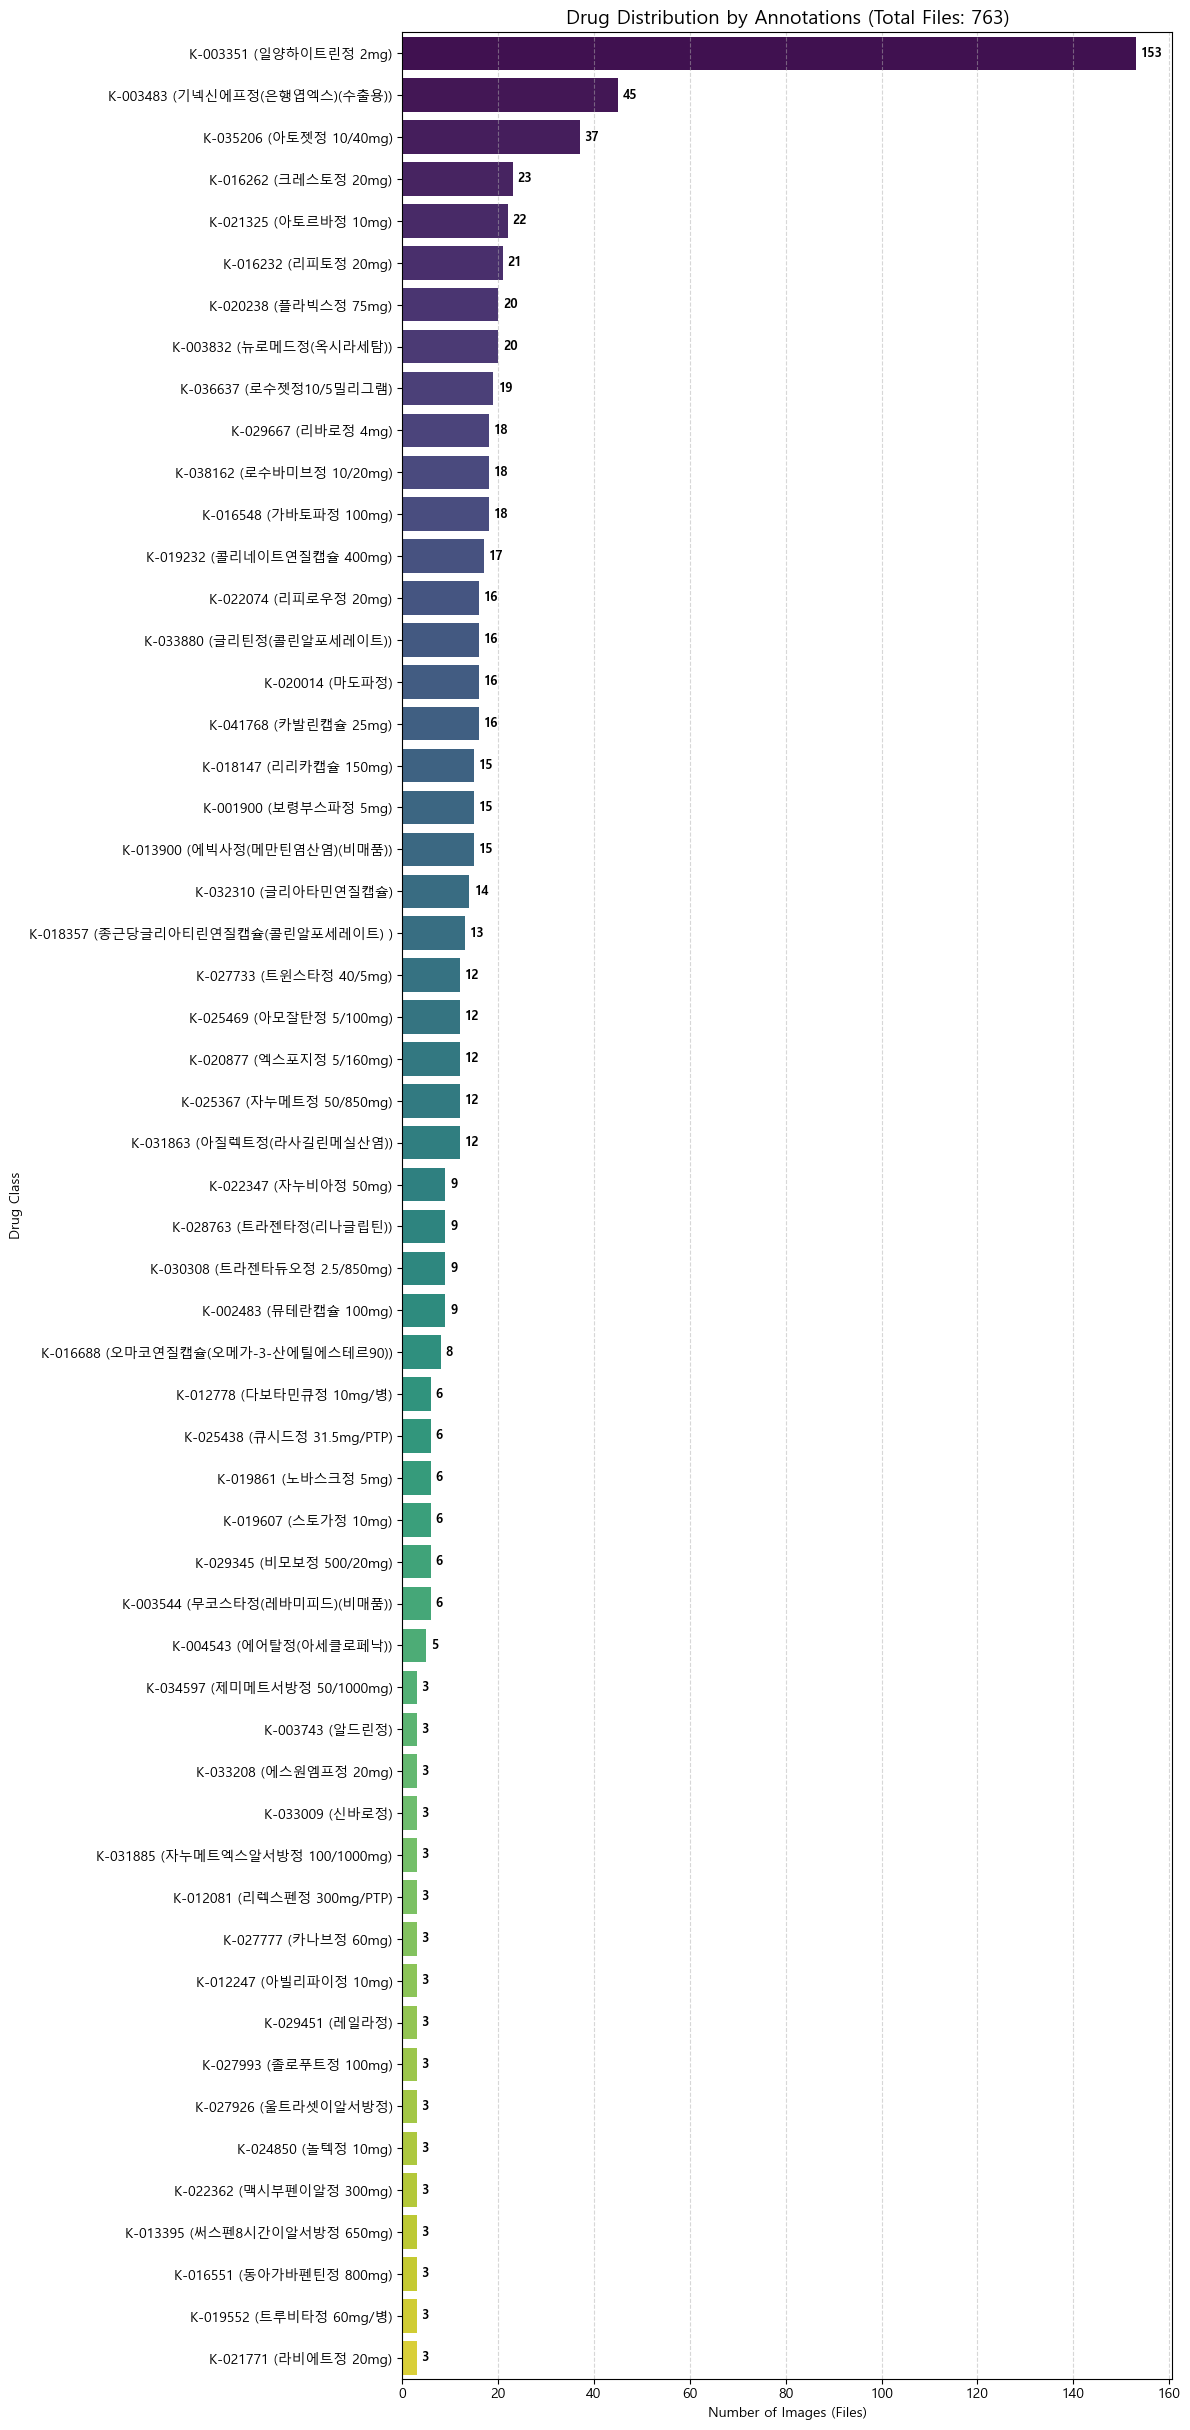

In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # 진행률 표시바

# ========================================================
# 📂 설정: JSON 파일들이 들어있는 최상위 폴더 경로
# ========================================================
root_path = r"C:\Users\home\Desktop\AI_study\data\train_annotations"

# ========================================================
# 🚀 메인 로직: JSON 파일 순회 및 데이터 수집
# ========================================================
data_list = []

print(f"📂 '{root_path}' 폴더 내의 모든 JSON 파일을 검색 중입니다...")

# 1. 모든 json 파일 경로 찾기
json_files = []
for root, dirs, files in os.walk(root_path):
    for file in files:
        if file.lower().endswith('.json'):
            json_files.append(os.path.join(root, file))

if not json_files:
    print("❌ JSON 파일을 찾지 못했습니다. 경로를 다시 확인해주세요.")
else:
    print(f"✅ 총 {len(json_files)}개의 파일을 발견했습니다. 분석을 시작합니다...")

    # 2. 파일 하나씩 열어서 정보 추출 (tqdm으로 진행바 표시)
    for file_path in tqdm(json_files):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
                # 📌 제공해주신 JSON 구조에 맞춘 파싱 로직
                if 'images' in data and len(data['images']) > 0:
                    img_info = data['images'][0]
                    
                    # 약 ID 추출 (drug_N 우선, 없으면 dl_mapping_code)
                    drug_id = img_info.get('drug_N') or img_info.get('dl_mapping_code')
                    
                    # 약 이름 추출
                    drug_name = img_info.get('dl_name')
                    
                    if drug_id and drug_name:
                        data_list.append({
                            'Drug_ID': drug_id,
                            'Drug_Name': drug_name
                        })
                        
        except Exception as e:
            # 깨진 파일이 있어도 멈추지 않고 건너뜀
            print(f"⚠️ 읽기 실패 ({os.path.basename(file_path)}): {e}")

# ========================================================
# 📊 데이터 집계 및 시각화
# ========================================================
if data_list:
    df = pd.DataFrame(data_list)
    
    # 1. 약 종류별 개수 세기
    df_counts = df.groupby(['Drug_ID', 'Drug_Name']).size().reset_index(name='Count')
    
    # 2. 그래프 라벨 만들기: "K-001900 (보령부스파정 5mg)"
    df_counts['Label'] = df_counts['Drug_ID'] + " (" + df_counts['Drug_Name'] + ")"
    
    # 3. 개수 많은 순서대로 정렬 (상위 데이터 파악용)
    df_counts = df_counts.sort_values(by='Count', ascending=False)
    
    print("\n✅ 데이터 집계 완료!")
    print(f"총 {len(df_counts)}종류의 약이 발견되었습니다.")
    print("-" * 50)
    print(df_counts.head())  # 상위 5개 출력

    # 4. 그래프 그리기
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
    plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

    # 데이터 양에 따라 그래프 세로 길이 자동 조절 (약 1개당 0.4인치)
    plt.figure(figsize=(12, len(df_counts) * 0.4 + 2))
    
    # 막대 그래프
    ax = sns.barplot(data=df_counts, x='Count', y='Label', palette='viridis')
    
    # 막대 끝에 숫자 표시
    for i, v in enumerate(df_counts['Count']):
        ax.text(v + 1, i, str(v), va='center', fontsize=9, fontweight='bold')
        
    plt.title(f'Drug Distribution by Annotations (Total Files: {len(data_list)})', fontsize=14)
    plt.xlabel('Number of Images (Files)')
    plt.ylabel('Drug Class')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # 저장 및 출력
    save_path = os.path.join(root_path, "Drug_Count_Graph.png")
    plt.savefig(save_path, dpi=300)
    print(f"\n📊 그래프가 저장되었습니다: {save_path}")
    plt.show()

else:
    print("\n❌ 데이터를 추출하지 못했습니다. JSON 구조가 예상과 다른 파일들이 있을 수 있습니다.")